### Pipeline to train model with XgBoost without train test split and using s9 for testing instead
- Testing:
```
Accuracy: 0.9655411421158527
              precision    recall  f1-score   support

           0       0.96      1.00      0.98   1634501
           1       0.99      0.85      0.91    444500

    accuracy                           0.97   2079001
   macro avg       0.98      0.92      0.95   2079001
weighted avg       0.97      0.97      0.96   2079001
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the datasets

In [2]:
df_1 = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


### Combine dataset

In [3]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

### Drop duplicates

In [4]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### Data filtering

In [5]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorization

In [6]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

### handle -ve EMG

In [7]:
df["EMG"] = df["EMG"].abs()

### Handling the -Ve temp value

In [8]:
df = df[df["Temp"] > 0]

### Balance out the train dataset only

In [9]:
from sklearn.utils import resample

# majority class
low_stress = df[df["Label"] == 0]

# minority class
high_stress = df[df["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

df = pd.concat([low_downsampled, high_stress]).sample(frac=1)

df['Label'].value_counts()

Label
1    1329917
0    1329917
Name: count, dtype: int64

### Load the test dataset

In [10]:
test = pd.read_csv("../Dataset/S4_chest_data.csv")

In [11]:
# filtering the dataset
accept_label = [1, 2, 3, 4]
test = test[test["Label"].isin(accept_label)]

# categorization
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

test["Label"] = test["Label"].apply(apply_target)

# handling -ve EMG value
test["EMG"] = test["EMG"].abs()


### Train the model

In [12]:
x_train = df.drop("Label", axis=1)
y_train = df["Label"]

y_test = test["Label"]
x_test = test.drop("Label", axis=1)

In [13]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 4,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    x_train, y_train,
    eval_set              = [(x_train, y_train), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.60536	validation_1-logloss:0.57075
[10]	validation_0-logloss:0.18631	validation_1-logloss:0.38453
[20]	validation_0-logloss:0.08159	validation_1-logloss:0.29967
[30]	validation_0-logloss:0.02627	validation_1-logloss:0.21351
[40]	validation_0-logloss:0.01433	validation_1-logloss:0.20756
[50]	validation_0-logloss:0.00772	validation_1-logloss:0.17979
[60]	validation_0-logloss:0.00345	validation_1-logloss:0.16174
[70]	validation_0-logloss:0.00175	validation_1-logloss:0.15682
[80]	validation_0-logloss:0.00089	validation_1-logloss:0.15753
[90]	validation_0-logloss:0.00053	validation_1-logloss:0.18376
[99]	validation_0-logloss:0.00033	validation_1-logloss:0.19371


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Test the model with test dataset

In [14]:
y_pred = model.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["Label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9655411421158527
              precision    recall  f1-score   support

           0       0.96      1.00      0.98   1634501
           1       0.99      0.85      0.91    444500

    accuracy                           0.97   2079001
   macro avg       0.98      0.92      0.95   2079001
weighted avg       0.97      0.97      0.96   2079001



### LIME

In [20]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=df.drop("Label", axis=1).values,
    feature_names=df.drop("Label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [19]:
print(explainer.scaler.mean_.shape)
print(explainer.scaler.scale_.shape)

(9,)
(9,)


In [21]:
input_data = pd.DataFrame([{
    "ACC_X": 1.2,
    "ACC_Y": -0.5,
    "ACC_Z":-1.0,
    "ECG": 0.5,
    "EMG": 0.1,
    "EDA": 9.2,
    "Temp": 29.30,
    "Resp": -0.40
}])



explanation = explainer.explain_instance(
    data_row=input_data.iloc[0].values,   
    predict_fn=model.predict_proba,
    num_features=8
)

explanation.as_list()

[('Temp', 0.016016230118790047),
 ('ACC_Z', 0.01534409348801443),
 ('EMG', -0.008899383938878267),
 ('ACC_Y', 0.007155503461050136),
 ('ECG', -0.004094953021171102),
 ('EDA', -0.002031797923004676),
 ('ACC_X', -0.0015623464050463416),
 ('Resp', -0.0001995697488970236)]

In [53]:
model.classes_

array([0, 1])

In [22]:
model.predict_proba(input_data)

array([[9.9977142e-01, 2.2861215e-04]], dtype=float32)

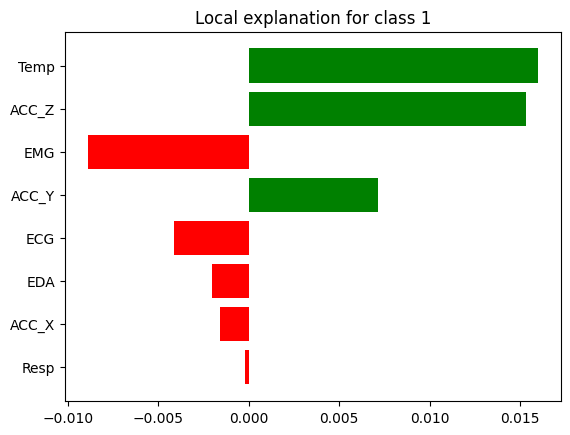

In [23]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

### SHAP

In [24]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


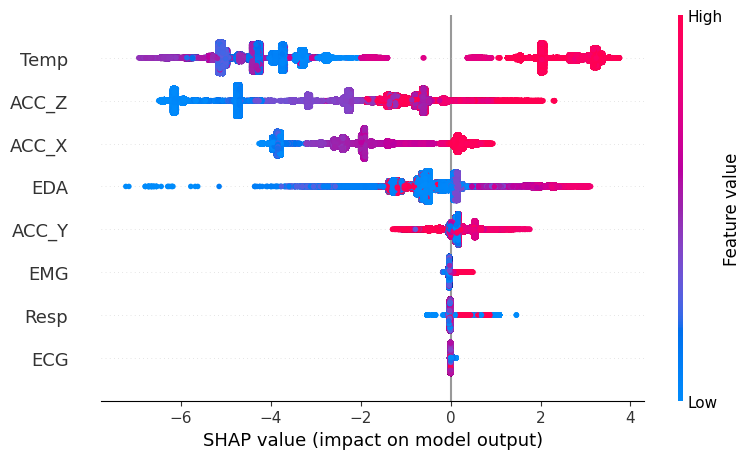

In [25]:
shap.summary_plot(shap_values, x_test)